In [2]:
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy import ndimage
import pandas as pd

Partial Differential Equations 

@autor:     Dario Hug
@date:      04.11.2024

**Assignment**: 
Solve the Poisson equation for the electromagnetic potential on a square grid as described in the lecture, with boundary conditions 
given by a 1000 Volt stick in the center of a 0 Volt box (as depicted in the lecture notes).

1) Use the Jacobi method on a 100x100 grid first with nested loops and then using the checkerboard implementation with either the numpy 
or the convolution way shown in the exercise class. Note duration and the number of iterations needed to reach convergence. Make a contour 
and a color plot of the resulting potential.

2) Use the SOR method (using the checkerboard implementation) with omega=1.9 on a 100x100 grid and note the duration and the number of 
iterations needed to reach convergence. Make the plots again and compare to the result obtained with the Jacobi method.

3) Find the best omega (best meaning the lowest number of iterations needed for convergence) for different numbers of grid points: 
N=10, 20, 50, 100, 200, 500, 1000 with SOR and create a table with the result you found.

**Comment**: 
This took me quite some time and also pushed my 2018 Lenovo Thinkpad to its limits. I took lots of inspiration from @Jeffrey_Chasnov and @3Blue1brown who both have good PDE Series on Youtube. Links: [Link Jeffrey_Chasnov](https://www.youtube.com/watch?v=QpzOttega9s) and [Link 3Blue1brown](https://www.youtube.com/watch?v=p_di4Zn4wz4&list=PLZHQObOWTQDNPOjrT6KVlfJuKtYTftqH6). My computer broke down twice when trying to run the SOR Method on the 500> size grids. I'm not sure if this is due to a faulty code or to a lack of computer power. The Trend at least seems to be that the Algo performs better on larger grids with larger Omega. 

**Method**: 
We solve the PDE of a electromagnetic potential on a square grid via three methods: **jacobi_nested_loops()**, **jacobi_checkerboard()** and **SOR_checkerboard()**, which increase in efficiency. For each method we plot the resulting Electric field as well as the Number of Iterations and the computation time it took. Also we try to find the optimal Omegas for different Sizes of grids. The trend here seems to be, that for larger grids the omega should grow as well. #TODO 

In [ ]:
def jacobi_nested_loops(U, tolerance, max_iterations, grid_size, grid_center):
    U_new = U.copy()
    iterations = 0
    start_time = time.time()

    while iterations < max_iterations:
        
        difference = 0
        
        # Jacobi update with nested loops
        for i in range(1, grid_size - 2):
            for j in range(1, grid_size - 2):
                if (i, j) in grid_center:
                    continue
                U_new[i, j] = 0.25 * (U[i + 1, j] + U[i - 1, j] + U[i, j + 1] + U[i, j - 1])
                difference = max(difference, abs(U_new[i, j] - U[i, j]))

        U[:] = U_new  # A cool command I found on reddit which shall be more memory efficient
        iterations += 1

        # print(difference)
        if difference < tolerance:
            break

    end_time = time.time()
    duration = end_time - start_time
    return U, iterations, duration

In [ ]:
grid_size = 100
tolerance = 1e-2
center_value = 1000.0 
max_iterations = 5000

# Initialize grid and boundary conditions
U = np.zeros((grid_size, grid_size))
grid_center = [(x, y) for x, y in np.ndindex(U.shape) if 48 < x < 52 and 30 < y < 70]
for node in grid_center:
    U[node[0], node[1]] = center_value

U_jacobi, jacobi_iterations, jacobi_duration = jacobi_nested_loops(U.copy(), tolerance, max_iterations, grid_size, grid_center)

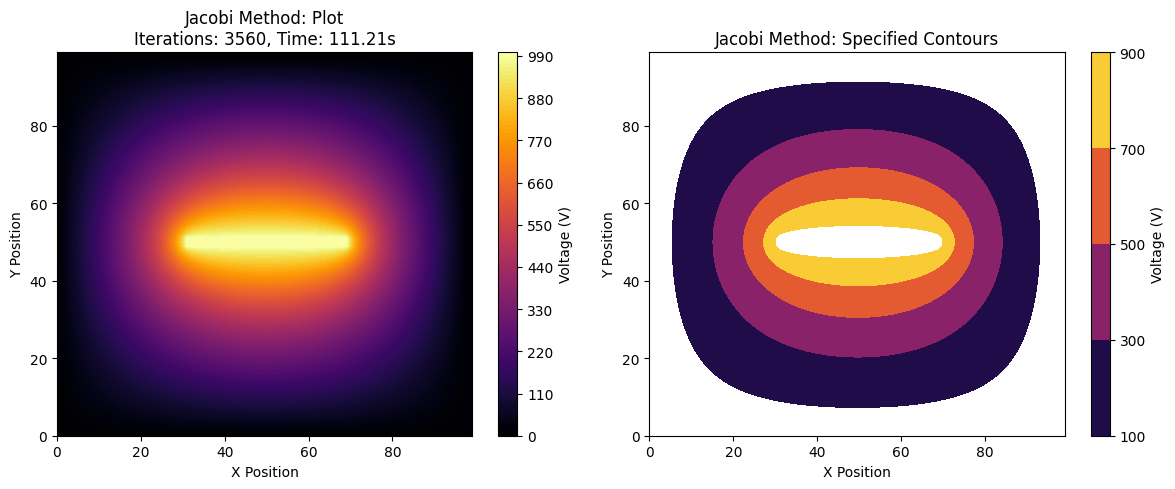

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.contourf(U_jacobi, 100, cmap="inferno")
plt.colorbar(label="Voltage (V)")
plt.title(f"Jacobi Method: Plot\nIterations: {jacobi_iterations}, Time: {jacobi_duration:.2f}s")
plt.xlabel("X Position")
plt.ylabel("Y Position")

plt.subplot(1, 2, 2)
contour_levels = [100, 300, 500, 700, 900]
plt.contourf(U_jacobi, levels=contour_levels, cmap="inferno")
plt.colorbar(label="Voltage (V)")
plt.title("Jacobi Method: Specified Contours")
plt.xlabel("X Position")
plt.ylabel("Y Position")

plt.tight_layout()
plt.show()


### Jacoby in Checker Format

In [ ]:
def jacobi_checkerboard(U, tolerance, max_iterations):
    
    iterations = 0
    start_time = time.time()

    U_new = np.ones_like(U)

    # We create checkerboard pattern for r/b cells
    checker_bool_grid = np.ones_like(U, dtype=bool)
    for x, y in np.ndindex(U.shape):
        checker_bool_grid[x, y] = (x % 2 == y % 2)

    # Mask of grid center where we dont want to change values
    center_bool_grid = np.ones_like(U, dtype=bool)
    for x, y in np.ndindex(U.shape):
        center_bool_grid[x, y] = (x, y) not in grid_center

    difference = 1
    nsteps = 0

    while difference >= tolerance and nsteps < max_iterations:
        U_prev = U.copy()

        red_update_mask = np.logical_and(checker_bool_grid, center_bool_grid)
        black_update_mask = np.logical_and(~checker_bool_grid, center_bool_grid)

        # Apply convolution for red points
        ndimage.convolve(U, np.array([[0, 1, 0], [1, 0, 1], [0, 1, 0]]), output=U_new, mode="constant", cval=0)
        U[red_update_mask] = 0.25 * U_new[red_update_mask]
        
        # Now the black points
        ndimage.convolve(U, np.array([[0, 1, 0], [1, 0, 1], [0, 1, 0]]), output=U_new, mode="constant", cval=0)
        U[black_update_mask] = 0.25 * U_new[black_update_mask]

        difference = np.max(np.abs(U - U_prev))

        nsteps += 1
        iterations += 1

    duration = time.time() - start_time
    return U, iterations, duration

In [ ]:
grid_size = 100
tolerance = 1e-3
center_value = 1000.0 
max_iterations = 10000


# Reset the Grid
U = np.zeros((grid_size, grid_size))
grid_center = [(x, y) for x, y in np.ndindex(U.shape) if 48 < x < 52 and 30 < y < 70]
for node in grid_center:
    U[node[0], node[1]] = center_value

# Run optimized Jacobi with checkerboard method
U_jacobi_checker, jacobi_checker_iterations, jacobi_checker_duration = jacobi_checkerboard(U.copy(), tolerance, max_iterations)

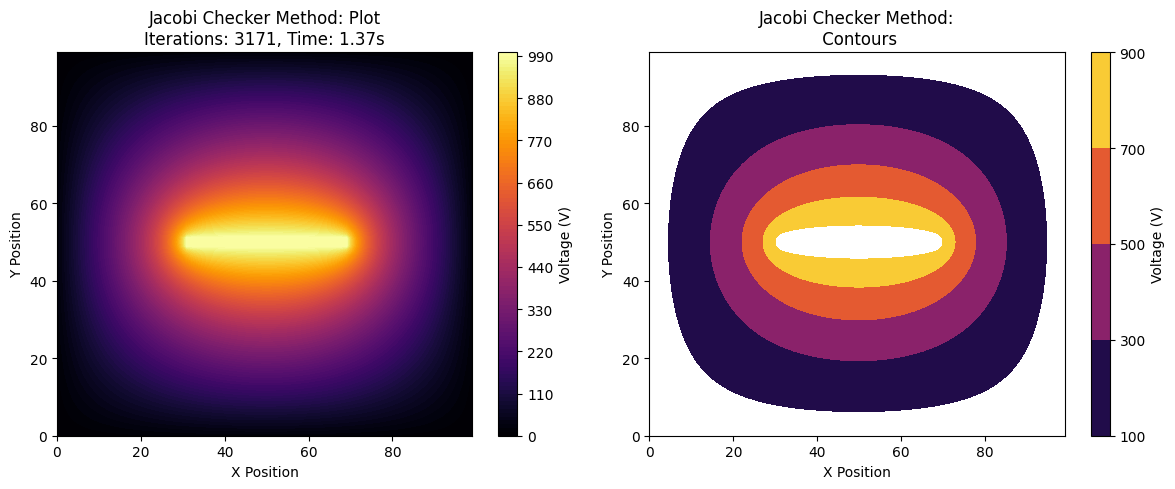

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.contourf(U_jacobi_checker, 100, cmap="inferno")
plt.colorbar(label="Voltage (V)")
plt.title(f"Jacobi Checker Method: Plot\nIterations: {jacobi_checker_iterations}, Time: {jacobi_checker_duration:.2f}s")
plt.xlabel("X Position")
plt.ylabel("Y Position")

plt.subplot(1, 2, 2)
contour_levels = [100, 300, 500, 700, 900]
plt.contourf(U_jacobi_checker, levels=contour_levels, cmap="inferno")
plt.colorbar(label="Voltage (V)")
plt.title("Jacobi Checker Method:\n Contours")
plt.xlabel("X Position")
plt.ylabel("Y Position")

plt.tight_layout()
plt.show()

### Successive Over Relaxation SOR ###

In [4]:
def SOR_checkerboard(U, tolerance, max_iterations, omega):
    
    iterations = 0
    start_time = time.time()

    U_new = np.ones_like(U)
    magnitude_grid = np.ones_like(U)  # We store the Updates

    # We create checkerboard pattern for r/b cells
    checker_bool_grid = np.ones_like(U, dtype=bool)
    for x, y in np.ndindex(U.shape):
        checker_bool_grid[x, y] = (x % 2 == y % 2)

    # Mask of grid center where we dont want to change values
    center_bool_grid = np.ones_like(U, dtype=bool)
    for x, y in np.ndindex(U.shape):
        center_bool_grid[x, y] = (x, y) not in grid_center

    diff = np.max(np.abs(magnitude_grid))
    nsteps = 0

    while diff >= tolerance and nsteps < max_iterations:
        magnitude_grid = np.zeros_like(U)

        red_update_mask = np.logical_and(checker_bool_grid, center_bool_grid)
        black_update_mask = np.logical_and(~checker_bool_grid, center_bool_grid)

        # Apply convolution for red points
        ndimage.convolve(U, np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]]), output=U_new, mode="constant", cval=0)
        magnitude_grid[red_update_mask] = 0.25 * U_new[red_update_mask]
        U[red_update_mask] += omega * magnitude_grid[red_update_mask]  

        # Now the black points
        ndimage.convolve(U, np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]]), output=U_new, mode="constant", cval=0)
        magnitude_grid[black_update_mask] = 0.25 * U_new[black_update_mask]
        U[black_update_mask] += omega * magnitude_grid[black_update_mask] 

        diff = np.max(np.abs(magnitude_grid))

        nsteps += 1
        iterations += 1

    duration = time.time() - start_time
    return U, iterations, duration

In [ ]:
grid_size = 100
tolerance = 1e-3
center_value = 1000.0 
max_iterations = 10000
omega = 1.5

U = np.zeros((grid_size, grid_size))
grid_center = [(x, y) for x, y in np.ndindex(U.shape) if 48 < x < 52 and 30 < y < 70]
for node in grid_center:
    U[node[0], node[1]] = center_value


U_sor, sor_iterations, sor_duration = SOR_checkerboard(U.copy(), tolerance, max_iterations, omega)

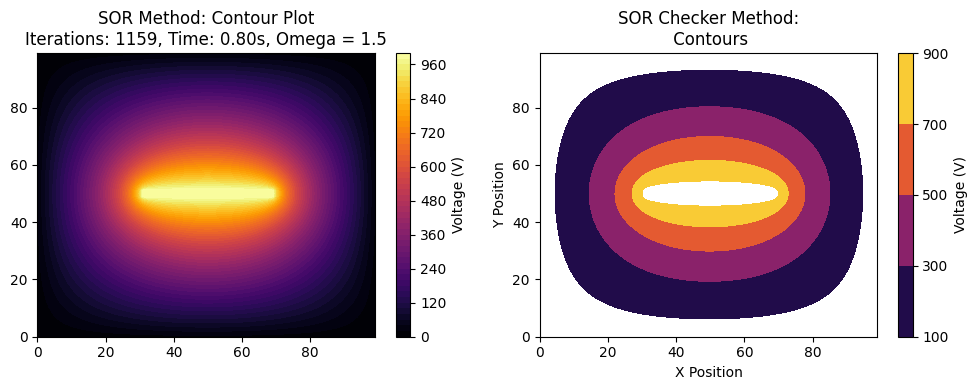

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.contourf(U_sor, 50, cmap="inferno")
plt.colorbar(label="Voltage (V)")
plt.title(f"SOR Method: Contour Plot\nIterations: {sor_iterations}, Time: {sor_duration:.2f}s, Omega = {omega}")

plt.subplot(1, 2, 2)
contour_levels = [100, 300, 500, 700, 900]
plt.contourf(U_sor, levels=contour_levels, cmap="inferno")
plt.colorbar(label="Voltage (V)")
plt.title("SOR Checker Method:\n Contours")
plt.xlabel("X Position")
plt.ylabel("Y Position")


plt.tight_layout()
plt.show()

### Create Table (Best Omega for size of Table) ###

In [ ]:
grid_sizes = [10, 20, 50, 100, 200]
tolerance = 1e-3
center_value = 1000.0 
max_iterations = 10000
results = {}

time_limits = {
    10: 30,
    20: 30,
    50: 30,
    100: 30,
    200: 60,
}

for size in grid_sizes:
    print(f"--- {size} ---")
    U = np.zeros((size, size))
    
    # Define center region of each grid dynamicaly 
    grid_center = [(x, y) for x, y in np.ndindex(U.shape) 
                   if (size // 2 - size // 25) <= x <= (size // 2 + size // 25) and
                   (size // 2 - size // 5) <= y <= (size // 2 + size // 5)]
    
    for node in grid_center:
        U[node[0], node[1]] = center_value

    optimal_omega = 1.5
    best_duration = float('inf')
    step_size = 0.25 
    start_time = time.time()

    nr_of_optimizations = 0
    
    while time.time() - start_time < time_limits[size]:
        U_sor, sor_iterations, sor_duration = SOR_checkerboard(U.copy(), tolerance, max_iterations, optimal_omega)

        results[size] = (optimal_omega, sor_iterations, sor_duration, nr_of_optimizations)
        
        # We adjust omega based on performance in decreasing stepssizes
        if sor_duration < best_duration:
            best_duration = sor_duration
            if optimal_omega + step_size <= 2.0:
                optimal_omega += step_size 
            else:
                break
        else:
            if optimal_omega - step_size >= 1.0:
                optimal_omega -= step_size

        step_size /= 2
        nr_of_optimizations += 1

--- 10 ---
--- 20 ---
--- 50 ---
--- 100 ---
--- 200 ---


In [34]:
df = pd.DataFrame.from_dict(results, orient='index', columns=['Optimal Omega', 'SOR Iterations', 'SOR Duration', 'Nr of Optimizations'])

df.index.name = 'Gridsize'
print(df)

          Optimal Omega  SOR Iterations  SOR Duration  Nr of Optimizations
Gridsize                                                                  
10             1.515991              21      0.001261                22490
20             1.751953              46      0.004218                 7442
50             1.875309              96      0.028399                 1127
100            1.938759             195      0.189826                  150
200            1.969250             385      1.880061                   25
